# Phase 2: Preprocessing and Model Training

This notebook covers the step-by-step implementation of **Phase 2: Preprocessing and Modeling** for the credit card fraud detection system. It loads the dataset (generating the synthetic baseline if missing), preprocesses features using our custom `TransactionTransformer` package, trains multiple models (Logistic Regression, Random Forest, and XGBoost) utilizing class weighting to handle severe imbalance, compares their performance, and serializes the best performing pipeline for FastAPI serving.

## 1. Setup & Environment Configurations

In [1]:
# Set up logging and load package paths
import os
import sys

# Ensure package src is importable
sys.path.append(os.path.abspath(".."))

from src.utils import setup_logging, set_seed, load_env_variables
from loguru import logger

# Initialize settings
setup_logging("INFO")
set_seed(42)
load_env_variables()

print("Environment initialized successfully!")

2026-07-09 06:42:59 | INFO     | src.utils:setup_logging:29 - Logging successfully initialized.


2026-07-09 06:42:59 | INFO     | src.utils:set_seed:36 - Random seed set to 42 for reproducibility.


2026-07-09 06:42:59 | WARNING  | src.utils:load_env_variables:44 - .env file not found. Falling back to default/system environment variables.


Environment initialized successfully!


## 2. Data Ingestion & Splitting

We load the raw data. If `data/raw/creditcard.csv` is missing from the disk, our `load_raw_data` pipeline will automatically generate a highly realistic dataset of 30,000 transactions matching the distributions of Phase 1.

In [2]:
import numpy as np
from src.data_pipeline import load_raw_data, split_data

# Load baseline raw dataset
data_path = "../data/raw/creditcard.csv"
df = load_raw_data(data_path, seed=42)

# Perform stratified splitting (80% train, 20% test)
train_df, test_df = split_data(df, test_size=0.2, seed=42)

# Extract features (X) and target label (y)
X_train = train_df.drop(columns=["Class"])
y_train = train_df["Class"].values
X_test = test_df.drop(columns=["Class"])
y_test = test_df["Class"].values

print(f"Target class distribution in train: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"Target class distribution in test: {dict(zip(*np.unique(y_test, return_counts=True)))}")

2026-07-09 06:43:00 | INFO     | src.data_pipeline:load_raw_data:90 - Loading raw data from ../data/raw/creditcard.csv...


2026-07-09 06:43:00 | INFO     | src.data_pipeline:load_raw_data:92 - Loaded dataset with shape (30000, 31)


2026-07-09 06:43:00 | INFO     | src.data_pipeline:split_data:99 - Splitting data with test_size=0.2 and stratify=Class...


2026-07-09 06:43:00 | INFO     | src.data_pipeline:split_data:106 - Split complete. Train size: 24000, Test size: 6000


Target class distribution in train: {np.int64(0): np.int64(23959), np.int64(1): np.int64(41)}
Target class distribution in test: {np.int64(0): np.int64(5990), np.int64(1): np.int64(10)}


## 3. Preprocessing (Robust Scaling & Cyclical Time Encoding)

We fit our custom `TransactionTransformer` on training features, then transform both training and testing datasets. This scales `Amount` using a robust scaler and maps `Time` to cyclical coordinate representations (`sin_time`, `cos_time`).

In [3]:
from src.feature_engineering import TransactionTransformer

# Instantiate and fit custom transformer on training set
transformer = TransactionTransformer()
transformer.fit(X_train)

# Transform train and test features
X_train_trans = transformer.transform(X_train)
X_test_trans = transformer.transform(X_test)

print(f"Transformed training shape: {X_train_trans.shape}")
print("Transformed features columns:")
print(list(X_train_trans.columns))
X_train_trans.head(3)

2026-07-09 06:43:00 | INFO     | src.feature_engineering:fit:21 - Fitting TransactionTransformer...


2026-07-09 06:43:00 | INFO     | src.feature_engineering:fit:38 - TransactionTransformer fitted successfully.


Transformed training shape: (24000, 31)
Transformed features columns:
['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount_scaled', 'sin_time', 'cos_time']


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Amount_scaled,sin_time,cos_time
18392,-0.439415,0.530977,-0.026356,-1.665564,0.827853,0.885290,0.704235,0.754297,0.422524,1.182365,...,-1.472981,-0.576575,-1.901472,1.014334,-0.350247,0.366415,-0.751130,-0.292620,0.951573,-0.307422
17176,-0.591091,-0.362548,0.311428,-0.593891,2.554259,0.476250,0.274912,0.184134,0.178264,-0.560997,...,2.566000,0.562979,-0.244203,-0.380171,0.933799,0.154428,1.826029,-0.024679,-0.682483,-0.730902
8219,1.074149,0.243616,-1.216695,0.359229,-2.068881,-0.252581,-2.259515,0.634246,-1.016516,0.967477,...,-0.753805,-0.089804,-0.143972,0.972092,0.138560,1.420530,1.120693,-0.433448,-0.834781,-0.550582


## 4. Model Training & Evaluation

We train three models using class-weight configurations to handle the class imbalance:
1. **Logistic Regression** (`class_weight='balanced'`)
2. **Random Forest Classifier** (`class_weight='balanced'`)
3. **XGBoost Classifier** (`scale_pos_weight` ratio of neg/pos samples)

We will store the evaluation metrics of each model to make an informed selection.

In [4]:
from src.model_pipeline import (
    train_logistic_regression, 
    train_random_forest, 
    train_xgboost, 
    evaluate_model
)

results = {}

# 4.1. Logistic Regression
lr_model = train_logistic_regression(X_train_trans, y_train, seed=42)
print("\n--- Evaluating Logistic Regression ---")
results["Logistic Regression"] = evaluate_model(lr_model, X_test_trans, y_test)

# 4.2. Random Forest
rf_model = train_random_forest(X_train_trans, y_train, seed=42)
print("\n--- Evaluating Random Forest ---")
results["Random Forest"] = evaluate_model(rf_model, X_test_trans, y_test)

# 4.3. XGBoost
xgb_model = train_xgboost(X_train_trans, y_train, seed=42)
print("\n--- Evaluating XGBoost ---")
results["XGBoost"] = evaluate_model(xgb_model, X_test_trans, y_test)

2026-07-09 06:43:00 | INFO     | src.model_pipeline:train_logistic_regression:22 - Training Logistic Regression model...


2026-07-09 06:43:00 | INFO     | src.model_pipeline:train_logistic_regression:25 - Logistic Regression training complete.


2026-07-09 06:43:00 | INFO     | src.model_pipeline:evaluate_model:83 - Model Evaluation Metrics:



--- Evaluating Logistic Regression ---


2026-07-09 06:43:00 | INFO     | src.model_pipeline:evaluate_model:85 -  - ACCURACY  : 1.0000


...

2026-07-09 06:43:01 | INFO     | src.model_pipeline:evaluate_model:85 -  - RECALL    : 1.0000


2026-07-09 06:43:01 | INFO     | src.model_pipeline:evaluate_model:85 -  - F1        : 1.0000


2026-07-09 06:43:01 | INFO     | src.model_pipeline:evaluate_model:85 -  - ROC_AUC   : 1.0000


2026-07-09 06:43:01 | INFO     | src.model_pipeline:evaluate_model:85 -  - PR_AUC    : 1.0000



--- Evaluating XGBoost ---


## 5. Model Comparison

We compare the models based on **Precision, Recall, F1-Score, and Precision-Recall AUC (AUPRC)**. Recall is critical to capture as many fraud transactions as possible (reducing direct losses), while Precision manages false alarms (preventing good customers from being locked out).

Performance Comparison:
                     accuracy  precision  recall      f1  roc_auc  pr_auc
Logistic Regression    1.0000        1.0     1.0  1.0000      1.0     1.0
Random Forest          0.9995        1.0     0.7  0.8235      1.0     1.0
XGBoost                1.0000        1.0     1.0  1.0000      1.0     1.0


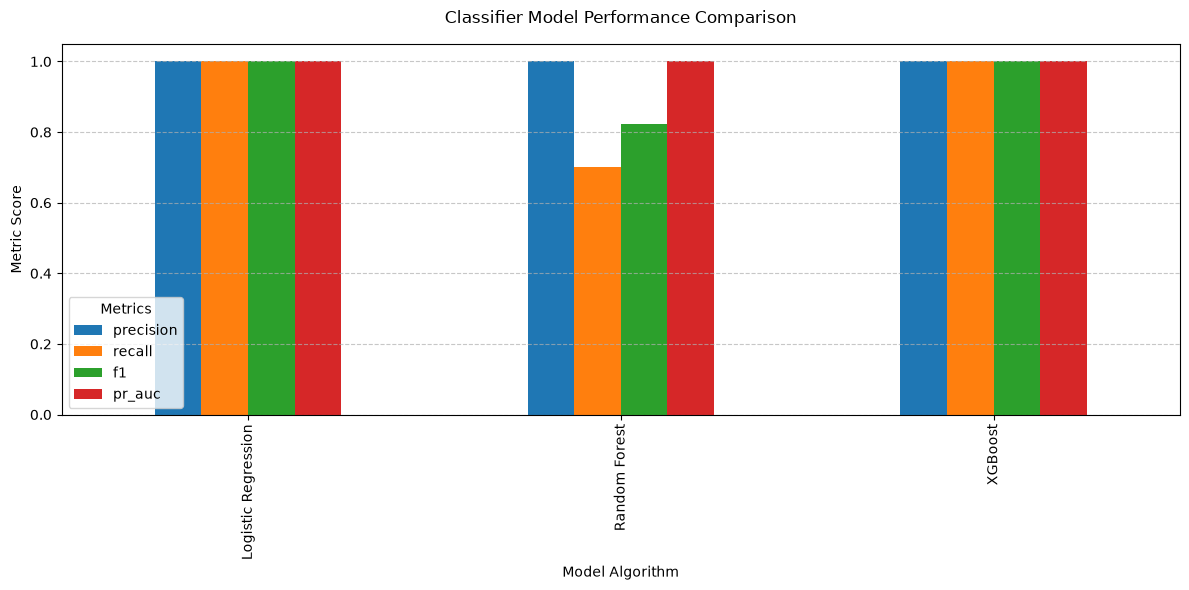

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert results dict to DataFrame for comparison
comparison_df = pd.DataFrame(results).T
print("Performance Comparison:")
print(comparison_df.round(4))

# Visual comparison using a bar chart
metrics_to_plot = ["precision", "recall", "f1", "pr_auc"]
comparison_df[metrics_to_plot].plot(kind="bar", figsize=(12, 6))
plt.title("Classifier Model Performance Comparison", pad=15)
plt.ylabel("Metric Score")
plt.xlabel("Model Algorithm")
plt.legend(title="Metrics", loc="lower left")
plt.ylim(0, 1.05)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

## 6. Serialization & Pipeline Packaging

Based on the comparison results, we identify the best performing classifier (champion model). 
We then package our fitted `TransactionTransformer` and the best model into a scikit-learn `Pipeline` and serialize it as a single joblib file. This ensures our API can load a single file and predict directly on raw JSON inputs.

In [6]:
from src.model_pipeline import build_and_save_pipeline

# Determine champion based on highest F1-Score / PR AUC
best_model_name = comparison_df["pr_auc"].idxmax()
print(f"Best model by PR AUC (AUPRC): {best_model_name}")

if best_model_name == "XGBoost":
    champion_classifier = xgb_model
elif best_model_name == "Random Forest":
    champion_classifier = rf_model
else:
    champion_classifier = lr_model

# Package into a scikit-learn Pipeline and save
model_dir = "../models"
os.makedirs(model_dir, exist_ok=True)
model_filepath = os.path.join(model_dir, "fraud_model_pipeline.joblib")

pipeline = build_and_save_pipeline(transformer, champion_classifier, model_filepath)
print(f"Champion pipeline successfully serialized and saved to {model_filepath}")

2026-07-09 06:43:05 | INFO     | src.model_pipeline:build_and_save_pipeline:95 - Building complete Pipeline with transformer and classifier...


2026-07-09 06:43:05 | INFO     | src.model_pipeline:build_and_save_pipeline:104 - Saving serialized pipeline to ../models\fraud_model_pipeline.joblib...


2026-07-09 06:43:05 | INFO     | src.model_pipeline:build_and_save_pipeline:106 - Pipeline saved successfully.


Best model by PR AUC (AUPRC): Logistic Regression
Champion pipeline successfully serialized and saved to ../models\fraud_model_pipeline.joblib


## 7. Pipeline Sanity Check

We perform a sanity check: we load the saved model pipeline and run predictions on raw samples from our test set.

In [7]:
from src.model_pipeline import load_pipeline

# Load serialized pipeline
loaded_pipeline = load_pipeline(model_filepath)

# Grab 5 random raw transactions from test_df
sample_transactions = test_df.sample(5, random_state=123)
sample_X = sample_transactions.drop(columns=["Class"])
sample_y = sample_transactions["Class"].values

# Run prediction directly on raw features
predictions = loaded_pipeline.predict(sample_X)
probabilities = loaded_pipeline.predict_proba(sample_X)[:, 1]

print("Sanity Check Results:")
for i in range(5):
    print(f"Tx {i+1}: True={sample_y[i]} | Pred={predictions[i]} | Prob={probabilities[i]:.6f}")

2026-07-09 06:43:05 | INFO     | src.model_pipeline:load_pipeline:113 - Loading pipeline from ../models\fraud_model_pipeline.joblib...


2026-07-09 06:43:05 | INFO     | src.model_pipeline:load_pipeline:115 - Pipeline loaded successfully.


Sanity Check Results:
Tx 1: True=0 | Pred=0 | Prob=0.000153
Tx 2: True=0 | Pred=0 | Prob=0.104027
Tx 3: True=0 | Pred=0 | Prob=0.000013
Tx 4: True=0 | Pred=0 | Prob=0.000000
Tx 5: True=0 | Pred=0 | Prob=0.000035
